Conditionally IID Observations

In [ ]:
!pip uninstall tensorflow

In [ ]:
!pip install tensorflow-gpu==2.0.0-alpha0

     |████████████████████████████████| 332.1MB 24kB/s 
     |████████████████████████████████| 419kB 12.7MB/s 
     |████████████████████████████████| 3.0MB 47.3MB/s 


In [ ]:
import tensorflow as tf
print(tf.__version__)

2.0.0-alpha0


In [ ]:
from __future__ import absolute_import, division, print_function, unicode_literals

import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.layers import Input, LSTM, Dense, Reshape

In [ ]:
input_dim = 7 # input dimensionality
mu_pre = np.zeros(input_dim) # pre-change mean
mu_post = np.ones(input_dim) # post-change mean

In [ ]:
# Training Data
batch_size = 32
num_batch = 100
data_size = batch_size * num_batch # number of data streams in the training data
timesteps = 2000 # length of a training data stream 
rho = 0.001 # geometric parameter
pre_label = np.array([0])
post_label = np.array([1])

x_train = []
y_train = []
for jj in range(data_size):
    tau = np.random.geometric(rho) # random change-point
    if tau > timesteps:
        data_i = mu_pre + np.random.randn(1,timesteps,input_dim)
        label_i = pre_label + np.zeros([1,timesteps,1])
    else:
        data_pre = mu_pre + np.random.randn(1,tau-1,input_dim)  
        data_post = mu_post + np.random.randn(1,timesteps-tau+1,input_dim) 
        data_i = np.concatenate((data_pre,data_post),axis=1)
        label_pre = pre_label + np.zeros([1,tau-1,1])
        label_post = post_label + np.zeros([1,timesteps-tau+1,1])
        label_i = np.concatenate((label_pre,label_post),axis=1)

    if x_train == []:
        x_train = data_i
    else:    
        x_train = np.concatenate((x_train,data_i),axis=0)

    if y_train == []:
        y_train = label_i 
    else:
        y_train = np.concatenate((y_train,label_i),axis=0)

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:24: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:29: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.


In [ ]:
print(x_train.shape)
print(y_train.shape)

(3200, 2000, 7)
(3200, 2000, 1)


In [ ]:
# Validation Data
val_size = 500
val_data_pre = mu_pre + np.random.randn(val_size,timesteps//2,input_dim) # for the validation data, assume a fixed change-point: tau = timesteps/2
val_data_post = mu_post + np.random.randn(val_size,timesteps//2,input_dim)
x_val = np.concatenate((val_data_pre,val_data_post),axis=1)

y_pre_val = pre_label + np.zeros([val_size,timesteps//2,1])
y_post_val = post_label + np.zeros([val_size,timesteps//2,1])
y_val = np.concatenate((y_pre_val,y_post_val),axis=1)

In [ ]:
# Build the Neural Network
model = tf.keras.Sequential() 
model.add(Input(shape=(timesteps,input_dim))) 
model.add(LSTM(16, return_sequences = True))  
model.add(Dense(10, activation='relu')) 
model.add(Dense(1, activation='sigmoid'))
model.summary() 

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
unified_lstm (UnifiedLSTM)   (None, 2000, 16)          1536      
_________________________________________________________________
dense (Dense)                (None, 2000, 10)          170       
_________________________________________________________________
dense_1 (Dense)              (None, 2000, 1)           11        
Total params: 1,717
Trainable params: 1,717
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# Offline Training Phase
history = model.fit(x_train, y_train,
          validation_data=(x_val, y_val),
          batch_size=batch_size,
          epochs=20)

Train on 3200 samples, validate on 500 samples
Epoch 1/20
3200/3200 [==============================] - 13s 4ms/sample - loss: 0.4241 - accuracy: 0.7835 - val_loss: 0.1524 - val_accuracy: 0.9927
Epoch 2/20
3200/3200 [==============================] - 6s 2ms/sample - loss: 0.0569 - accuracy: 0.9955 - val_loss: 0.0283 - val_accuracy: 0.9964
Epoch 3/20
3200/3200 [==============================] - 6s 2ms/sample - loss: 0.0185 - accuracy: 0.9970 - val_loss: 0.0155 - val_accuracy: 0.9973
Epoch 4/20
3200/3200 [==============================] - 6s 2ms/sample - loss: 0.0118 - accuracy: 0.9977 - val_loss: 0.0113 - val_accuracy: 0.9977
Epoch 5/20
3200/3200 [==============================] - 7s 2ms/sample - loss: 0.0090 - accuracy: 0.9981 - val_loss: 0.0090 - val_accuracy: 0.9981
Epoch 6/20
3200/3200 [==============================] - 6s 2ms/sample - loss: 0.0074 - accuracy: 0.9983 - val_loss: 0.0076 - val_accuracy: 0.9983
Epoch 7/20
3200/3200 [==============================] - 6s 2ms/sample - loss

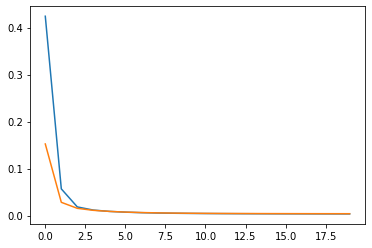

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [ ]:
model2 = tf.keras.Sequential()  # model2 has the same structure and weights with the trained network  
model2.add(Input(shape=(1,input_dim), batch_size=1)) # only difference is it takes single input a time, as usual in online stream processing
model2.add(LSTM(16, return_sequences = True, stateful=True))  # we have an explicit control on the internal RNN state: the RNN state is going to be reset for each new data stream       
model2.add(Dense(10, activation='relu')) 
model2.add(Dense(1, activation='sigmoid')) 
model2.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
unified_lstm_1 (UnifiedLSTM) (1, 1, 16)                1536      
_________________________________________________________________
dense_2 (Dense)              (1, 1, 10)                170       
_________________________________________________________________
dense_3 (Dense)              (1, 1, 1)                 11        
Total params: 1,717
Trainable params: 1,717
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model2.set_weights(model.get_weights()) 

**Performance Evaluation** **(Online Detection Phase)**

2) Minimax Setting

False Alarm Period Calculations

In [ ]:
# Data-Driven QCD Procedure 
test_size = 1000 # number of experiments 
h_vec = np.linspace(0.01,0.91,50) # test thresholds 
total_false_alarm_periods = np.zeros(len(h_vec)) # sum of the false alarm periods at each threshold over all experiments
for jj in range(test_size):
    if jj % 5 == 0:
        print(jj)
    # initialization for a new experiment
    t = 0 # time  
    model2.reset_states() # reset the internal RNN state for the new experiment
    alarm_flag_vec = np.zeros(len(h_vec)) # alarm flags for the new experiment
    # new experiment
    while alarm_flag_vec[-1] == 0:
        t += 1
        # observation at time t (always pre-change, no change happens at all)
        data_t = mu_pre + np.random.randn(1,1,input_dim)
        # decision statistic
        dec_stat = model2.predict(data_t) 
        dec_stat = dec_stat[0][0][0]        
        # update the alarm flags, the false alarm events, and the detection delays
        total_false_alarm_periods += t*(alarm_flag_vec == 0)*(dec_stat >= h_vec)
        alarm_flag_vec += (alarm_flag_vec == 0)*(dec_stat >= h_vec) 
         
# compute the average false alarm period (fap)
fap_vec_minimax = total_false_alarm_periods/test_size

In [ ]:
fap_vec_minimax

array([1.0000000e+00, 1.0000000e+00, 1.0000000e+00, 1.0000000e+00,
       1.0050000e+00, 2.6015000e+01, 8.2320000e+01, 1.1641500e+02,
       2.3737500e+02, 3.3144500e+02, 5.1919000e+02, 6.6053000e+02,
       8.4060500e+02, 1.0296650e+03, 1.2796250e+03, 1.4457300e+03,
       1.5809050e+03, 1.7480050e+03, 1.9768450e+03, 2.2000250e+03,
       2.4735800e+03, 2.6931900e+03, 2.9335250e+03, 3.1875650e+03,
       3.3149450e+03, 3.6517450e+03, 4.3241900e+03, 4.7809350e+03,
       5.1532900e+03, 5.4102800e+03, 6.0913400e+03, 6.7958050e+03,
       7.6423300e+03, 8.8432950e+03, 1.0108205e+04, 1.0742230e+04,
       1.1282535e+04, 1.2528100e+04, 1.4143440e+04, 1.5809040e+04,
       1.6787175e+04, 1.8987870e+04, 2.0565920e+04, 2.3095595e+04,
       2.6023095e+04, 3.0305350e+04, 3.6253435e+04, 4.7833845e+04,
       5.6526065e+04, 6.6013835e+04])

In [ ]:
# Benchmark: CUSUM Algorithm
test_size = 1000 # number of experiments 
h_vec = np.linspace(0.1,9,50) # test thresholds
cusum_false_alarm_periods = np.zeros(len(h_vec)) # sum of the false alarm periods at each threshold over all experiments
for jj in range(test_size):
    if jj % 50 == 0:
        print(jj)
    # initialization for a new experiment
    t = 0 # time  
    g = 0 # reset the CUSUM state for the new experiment
    cusum_flag_vec = np.zeros(len(h_vec)) # alarm flags for the new experiment
    # new experiment
    while cusum_flag_vec[-1] == 0:
        t += 1
        # observation at time t (pre-change)
        data_t = mu_pre + np.random.randn()
        # log-likelihood ratio
        LLR = 0.5*(np.matmul(data_t,np.transpose(data_t)) - np.matmul((data_t-mu_post),np.transpose(data_t-mu_post))) 
        # state update
        g = np.max([0, g + LLR])      
        # update the alarm flags, the false alarm events, and the detection delays
        cusum_false_alarm_periods += t*(cusum_flag_vec == 0)*(g >= h_vec)
        cusum_flag_vec += (cusum_flag_vec == 0)*(g >= h_vec) 
         
# compute the average false alarm period (fap)
cusum_fap_vec = cusum_false_alarm_periods/test_size

In [ ]:
cusum_fap_vec

array([1.2312000e+01, 1.3366000e+01, 1.5172000e+01, 1.6800000e+01,
       1.8864000e+01, 2.1468000e+01, 2.4658000e+01, 2.8256000e+01,
       3.1030000e+01, 3.6260000e+01, 4.4810000e+01, 5.1134000e+01,
       6.1226000e+01, 7.0310000e+01, 8.2942000e+01, 9.3814000e+01,
       1.1147000e+02, 1.3572200e+02, 1.5632200e+02, 1.8855400e+02,
       2.2146800e+02, 2.6620000e+02, 3.1227800e+02, 3.9684000e+02,
       4.6723200e+02, 5.8893200e+02, 7.0263200e+02, 8.7189800e+02,
       1.0533540e+03, 1.1914860e+03, 1.5020960e+03, 1.8244440e+03,
       2.0963340e+03, 2.5818020e+03, 3.0511760e+03, 3.6772000e+03,
       4.1254120e+03, 5.1599680e+03, 5.9529920e+03, 7.0540840e+03,
       8.1355200e+03, 1.0684440e+04, 1.2454638e+04, 1.4590732e+04,
       1.6765246e+04, 2.0419032e+04, 2.4139656e+04, 2.9545014e+04,
       3.6558908e+04, 4.7275750e+04])

In [ ]:
# Benchmark: SR Procedure
test_size = 1000 # number of experiments 
h_vec = np.linspace(1,20000,50)  # test thresholds
sr_false_alarm_periods = np.zeros(len(h_vec)) # sum of the false alarm periods at each threshold over all experiments
for jj in range(test_size):
    if jj % 50 == 0: 
        print(jj)
    # initialization for a new experiment
    t = 0 # time  
    g = 0 # reset the SR state for the new experiment
    sr_flag_vec = np.zeros(len(h_vec)) # alarm flags for the new experiment
    # new experiment
    while sr_flag_vec[-1] == 0:
        t += 1
        # observation at time t (pre-change)
        data_t = mu_pre + np.random.randn()
        # likelihood ratio 
        LR = np.exp(0.5*(np.matmul(data_t,np.transpose(data_t)) - np.matmul((data_t-mu_post),np.transpose(data_t-mu_post))))
        # state update
        g = (1+g)*LR     
        # update the alarm flags, the false alarm events, and the detection delays
        sr_false_alarm_periods += t*(sr_flag_vec == 0)*(g >= h_vec)
        sr_flag_vec += (sr_flag_vec == 0)*(g >= h_vec) 
         
# compute the average false alarm period (fap)
sr_fap_vec = sr_false_alarm_periods/test_size

In [ ]:
sr_fap_vec

array([9.7500000e+00, 1.8459160e+03, 3.7069320e+03, 5.4151960e+03,
       7.2771240e+03, 9.1201400e+03, 1.0728672e+04, 1.2269472e+04,
       1.5061444e+04, 1.7110592e+04, 1.9178384e+04, 2.0976890e+04,
       2.3159384e+04, 2.4461138e+04, 2.6492580e+04, 2.8584448e+04,
       3.1124570e+04, 3.2805058e+04, 3.4607820e+04, 3.6670412e+04,
       3.8757350e+04, 4.0850928e+04, 4.2439320e+04, 4.3908806e+04,
       4.5242884e+04, 4.7139778e+04, 4.9571012e+04, 5.1463048e+04,
       5.3588478e+04, 5.5589728e+04, 5.7561416e+04, 5.8590426e+04,
       6.1507576e+04, 6.3601806e+04, 6.5965998e+04, 6.7105144e+04,
       6.9043944e+04, 7.0704198e+04, 7.0873770e+04, 7.1925512e+04,
       7.3971392e+04, 7.5547862e+04, 7.8425386e+04, 8.1078544e+04,
       8.2443200e+04, 8.5181198e+04, 8.6370600e+04, 9.0628982e+04,
       9.1998650e+04, 9.4811290e+04])

Average Detection Delay Calculations (tau = 1)

In [ ]:
# Data-Driven QCD Procedure 
test_size = 10000 # number of experiments 
h_vec = np.linspace(0.01,0.91,50) # test thresholds
total_detection_delays = np.zeros(len(h_vec)) # sum of the detection delays at each threshold over all experiments
for jj in range(test_size):
    if jj % 1000 == 0:
        print(jj)
    # initialization for a new experiment
    t = 0 # time  
    model2.reset_states() # reset the internal RNN state for the new experiment
    alarm_flag_vec = np.zeros(len(h_vec)) # alarm flags for the new experiment
    # new experiment
    while alarm_flag_vec[-1] == 0:
        t += 1
        # observation at time t (always post-change, change happens at tau = 1)
        data_t = mu_post + np.random.randn(1,1,input_dim)
        # decision statistic
        dec_stat = model2.predict(data_t) 
        dec_stat = dec_stat[0][0][0]        
        # update the alarm flags, the false alarm events, and the detection delays
        total_detection_delays += (t-1)*(alarm_flag_vec == 0)*(dec_stat >= h_vec)
        alarm_flag_vec += (alarm_flag_vec == 0)*(dec_stat >= h_vec) 
         
# compute the average false alarm period (fap)
add_vec_minimax = total_detection_delays/test_size

In [ ]:
add_vec_minimax

array([0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e-04,
       4.0000e-04, 8.0000e-04, 1.3000e-03, 2.8000e-03, 4.3000e-03,
       6.9000e-03, 1.1100e-02, 1.6400e-02, 2.2600e-02, 3.1400e-02,
       3.7500e-02, 4.6100e-02, 5.4800e-02, 6.4800e-02, 7.3100e-02,
       8.5100e-02, 9.4400e-02, 1.0610e-01, 1.2000e-01, 1.3240e-01,
       1.4510e-01, 1.5880e-01, 1.7280e-01, 1.8580e-01, 2.0000e-01,
       2.1590e-01, 2.3680e-01, 2.5510e-01, 2.7870e-01, 3.0270e-01,
       3.2490e-01, 3.5220e-01, 3.8270e-01, 4.1430e-01, 4.4870e-01,
       4.8570e-01, 5.3020e-01, 5.7620e-01, 6.2820e-01, 6.8720e-01,
       7.5990e-01, 8.3890e-01, 9.2690e-01, 1.0394e+00, 1.1762e+00])

In [ ]:
# Benchmark: CUSUM Algorithm
test_size = 10000 # number of experiments 
h_vec = np.linspace(0.1,9,50) # test thresholds
cusum_detection_delays = np.zeros(len(h_vec)) # sum of the detection delays at each threshold over all experiments
for jj in range(test_size):
    if jj % 1000 == 0:
        print(jj)
    # initialization for a new experiment
    t = 0 # time  
    g = 0 # reset the CUSUM state for the new experiment
    cusum_flag_vec = np.zeros(len(h_vec)) # alarm flags for the new experiment
    # new experiment
    while cusum_flag_vec[-1] == 0:
        t += 1
        # observation at time t (post-change)
        data_t = mu_post + np.random.randn()
        # log-likelihood ratio
        LLR = 0.5*(np.matmul(data_t,np.transpose(data_t)) - np.matmul((data_t-mu_post),np.transpose(data_t-mu_post))) 
        # state update
        g = np.max([0, g + LLR])      
        # update the alarm flags, the false alarm events, and the detection delays
        cusum_detection_delays += (t-1)*(cusum_flag_vec == 0)*(g >= h_vec)
        cusum_flag_vec += (cusum_flag_vec == 0)*(g >= h_vec) 
         
# compute the average false alarm period (fap)
cusum_add_vec = cusum_detection_delays/test_size

In [ ]:
cusum_add_vec

array([0.1098, 0.124 , 0.1399, 0.1617, 0.1807, 0.2049, 0.231 , 0.257 ,
       0.2834, 0.3123, 0.3432, 0.3718, 0.4064, 0.4408, 0.4794, 0.5215,
       0.5643, 0.6112, 0.6583, 0.7072, 0.756 , 0.8044, 0.8515, 0.903 ,
       0.9516, 1.0046, 1.0566, 1.1077, 1.1607, 1.218 , 1.2747, 1.3281,
       1.381 , 1.4318, 1.488 , 1.5423, 1.5975, 1.6494, 1.7022, 1.7545,
       1.8096, 1.8623, 1.9167, 1.9707, 2.0277, 2.0807, 2.1372, 2.1861,
       2.2368, 2.2904])

In [ ]:
# Benchmark: SR Procedure
test_size = 10000 # number of experiments 
h_vec = np.linspace(1,20000,50)  # test thresholds
sr_detection_delays = np.zeros(len(h_vec)) # sum of the detection delays at each threshold over all experiments
for jj in range(test_size):
    if jj % 1000 == 0:
        print(jj)
    # initialization for a new experiment
    t = 0 # time  
    g = 0 # reset the SR state for the new experiment
    sr_flag_vec = np.zeros(len(h_vec)) # alarm flags for the new experiment
    # new experiment
    while sr_flag_vec[-1] == 0:
        t += 1
        # observation at time t (pre-change)
        data_t = mu_post + np.random.randn() 
        # likelihood ratio 
        LR = np.exp(0.5*(np.matmul(data_t,np.transpose(data_t)) - np.matmul((data_t-mu_post),np.transpose(data_t-mu_post))))
        # state update
        g = (1+g)*LR     
        # update the alarm flags, the false alarm events, and the detection delays
        sr_detection_delays += (t-1)*(sr_flag_vec == 0)*(g >= h_vec)
        sr_flag_vec += (sr_flag_vec == 0)*(g >= h_vec) 
         
# compute the average false alarm period (fap)
sr_add_vec = sr_detection_delays/test_size

In [ ]:
sr_add_vec

array([0.1023, 1.3726, 1.5754, 1.6966, 1.7781, 1.8391, 1.8936, 1.9369,
       1.9745, 2.0065, 2.0374, 2.0688, 2.0944, 2.118 , 2.1391, 2.1592,
       2.1778, 2.194 , 2.2085, 2.2268, 2.2397, 2.2537, 2.2656, 2.2819,
       2.2933, 2.3079, 2.318 , 2.3277, 2.3362, 2.3459, 2.3563, 2.3667,
       2.3764, 2.3853, 2.3939, 2.4016, 2.41  , 2.4164, 2.425 , 2.4341,
       2.4409, 2.448 , 2.4542, 2.462 , 2.4685, 2.4754, 2.4813, 2.4882,
       2.495 , 2.5012])

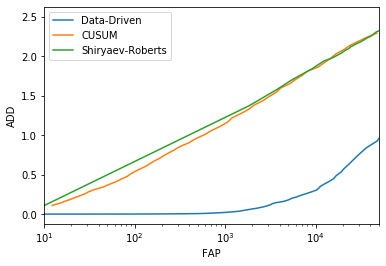

In [ ]:
plt.plot(fap_vec_minimax,add_vec_minimax)
plt.plot(cusum_fap_vec,cusum_add_vec)
plt.plot(sr_fap_vec,sr_add_vec)
plt.xlim(10,50000)
plt.xscale('log')
plt.xlabel('FAP')
plt.ylabel('ADD') 
plt.legend(["Data-Driven","CUSUM","Shiryaev-Roberts"]) 